# Pulsed Gaussian Source with PML on All Sides — FDTDX Tutorial

This notebook builds a small 3D FDTD simulation with [FDTDX](https://fdtdx.readthedocs.io/en/latest/):

1. A simulation volume surrounded by **PML absorbing boundaries on all six sides**.
2. A **pulsed Gaussian source** — a spatial Gaussian beam (`fdtdx.GaussianPlaneSource`) driven by a
   temporal Gaussian pulse envelope (`fdtdx.GaussianPulseProfile`), i.e. a short broadband flash of
   light rather than a continuous wave.
3. A simple **dielectric cube sitting in the middle of the volume** that the pulse scatters off.
4. A **`fdtdx.PhasorDetector`** that extracts the complex-valued (amplitude *and* phase) field
   components at several wavelengths simultaneously, all from a single broadband run.
5. A **dynamic stop condition** that automatically ends the simulation once (almost) all of the
   electromagnetic energy has left the volume, instead of always running for a fixed number of time
   steps.

In [42]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import fdtdx

from fdtdx.fdtd.stop_conditions import EnergyThresholdCondition

%matplotlib inline

## 1. Simulation configuration

`SimulationConfig.time` is only an **upper bound** on how long the simulation is allowed to run.
Because we're using a dynamic stop condition further down, the actual run will very likely end
well before this budget is used up, as soon as the pulse's energy has decayed away.


In [44]:
# --- grid & timing ---------------------------------------------------------
RESOLUTION = 100e-9      # 100 nm Yee-grid spacing
DOMAIN_X = 4e-6          # 4 µm
DOMAIN_Y = 4e-6          # 4 µm
DOMAIN_Z = 6e-6          # 6 µm (propagation axis)
PML_CELLS = 10           # PML thickness, in grid cells, on every side
SIM_TIME_MAX = 600e-15   # 600 fs upper bound - the dynamic stop condition will usually cut this short

key = jax.random.PRNGKey(42)

object_list = []
constraints = []

config = fdtdx.SimulationConfig(
    time=SIM_TIME_MAX,
    grid=fdtdx.UniformGrid(spacing=RESOLUTION),
    dtype=jnp.float32,
    courant_factor=0.99,
)

volume = fdtdx.SimulationVolume(
    partial_real_shape=(DOMAIN_X, DOMAIN_Y, DOMAIN_Z),
    material=fdtdx.Material(permittivity=1.0, permeability=1.0),  # vacuum background
)
object_list.append(volume)

print(f"Max time steps budget: {config.time_steps_total}")

Max time steps budget: 3147


## 2. PML on all six sides

`BoundaryConfig.from_uniform_bound(...)` is a shortcut that builds absorbing PML boundaries for
**all six faces** of the volume at once (instead of specifying each of the ±x/±y/±z faces by hand).


In [47]:
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=PML_CELLS, boundary_type="pml")
bound_dict, bound_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)

object_list.extend(bound_dict.values())
constraints.extend(bound_constraints)

print("PML boundaries created for:", list(bound_dict.keys()))

PML boundaries created for: ['min_x', 'max_x', 'min_y', 'max_y', 'min_z', 'max_z']


## 3. The pulsed Gaussian source

We build this in two independent pieces that FDTDX composes together:

- **Spatial shape** — `fdtdx.GaussianPlaneSource` emits a Gaussian-profile beam (as opposed to a flat
  `UniformPlaneSource`), with `radius`/`std` controlling how tightly it's focused transversely.
- **Temporal shape** — `temporal_profile=fdtdx.GaussianPulseProfile(...)` replaces the default
  continuous-wave drive with a short Gaussian *pulse* envelope, defined by a center wavelength
  (`center_wave`) and a spectral width (`spectral_width`).

Together these make a **pulsed Gaussian source**: spatially a Gaussian beam, temporally a Gaussian
pulse.


In [50]:
# --- carrier and probe wavelengths ------------------------------------------
CENTER_WAVELENGTH = 1.55e-6          # 1.55 µm carrier
SPECTRAL_WIDTH_HZ = 4e13             # pulse bandwidth (Hz) - controls the pulse duration
PROBE_WAVELENGTHS = [1.3e-6, 1.55e-6, 1.8e-6]   # the wavelengths we'll extract at complex fields

center_wave = fdtdx.WaveCharacter(wavelength=CENTER_WAVELENGTH)
spectral_width = fdtdx.WaveCharacter(frequency=SPECTRAL_WIDTH_HZ)

source = fdtdx.GaussianPlaneSource(
    name="Source",
    partial_grid_shape=(None, None, 1),          # a single-cell-thick plane ...
    partial_real_shape=(3e-6, 3e-6, None),        # ... spanning most of the x/y cross-section
    fixed_E_polarization_vector=(1, 0, 0),        # Ex-polarized
    wave_character=center_wave,                   # carrier wavelength (must match center_wave)
    temporal_profile=fdtdx.GaussianPulseProfile(
        center_wave=center_wave,
        spectral_width=spectral_width,
    ),
    radius=1.2e-6,
    std=1 / 3,
    direction="+",                                 # propagates toward +z
)
object_list.append(source)

# Place the source near the -z boundary, just inside the PML.
constraints.append(
    source.place_relative_to(
        volume,
        axes=(0, 1, 2),
        own_positions=(0, 0, -1),
        other_positions=(0, 0, -1),
        margins=(0, 0, PML_CELLS * RESOLUTION + 0.2e-6),
    )
)

## 4. A simple cube in the middle of the volume

A basic `fdtdx.UniformMaterialObject` gives the pulse something to scatter off, placed dead center
with `place_at_center`.


In [53]:
CUBE_SIZE = 1e-6  # 1 µm cube
CUBE_PERMITTIVITY = 4.0  # eps_r = 4  (n ≈ 2)

cube = fdtdx.UniformMaterialObject(
    name="Cube",
    partial_real_shape=(CUBE_SIZE, CUBE_SIZE, CUBE_SIZE),
    material=fdtdx.Material(permittivity=CUBE_PERMITTIVITY),
    color=fdtdx.colors.PINK,
)
object_list.append(cube)
constraints.append(cube.place_at_center(volume))

## 5. Multi-wavelength complex-field detector (`PhasorDetector`)

`fdtdx.PhasorDetector` accumulates the **complex** field phasor $E(\omega) = \int E(t)\, e^{i\omega t}\,dt$
at a *list* of wavelengths simultaneously, over a single broadband pulsed run — this is the whole
point of using a pulse instead of running one continuous-wave simulation per wavelength. Amplitude
and phase are recovered with `jnp.abs(...)` / `jnp.angle(...)`.

- `wave_characters=probe_waves` — the list of wavelengths we want complex fields at.
- `components=(...)` — which of `Ex, Ey, Ez, Hx, Hy, Hz` to record; we keep all six so we can also
  visualize the magnetic field.
- `scaling_mode="pulse"` — **important** when combined with a dynamic stop condition. The default
  `"continuous"` mode rescales the accumulated phasor by `2 / num_time_steps_recorded`, a normalization
  that assumes you know in advance how many steps will run (appropriate for steady-state CW sources).
  Since our run length is only known once the energy-threshold stop condition actually fires,
  `"pulse"` mode (no such rescaling) is the correct choice here.
- The detector spans a single-cell-thick plane in `y` (`partial_grid_shape=(None, 1, None)`) covering
  the full `x`/`z` extent, centered on the volume — i.e. a 2‑D cross-section through the source axis
  and the cube, which is what we'll plot below.


In [56]:
probe_waves = [fdtdx.WaveCharacter(wavelength=wl) for wl in PROBE_WAVELENGTHS]

field_detector = fdtdx.PhasorDetector(
    name="Fields",
    partial_grid_shape=(None, 1, None),
    wave_characters=probe_waves,
    components=("Ex", "Ey", "Ez", "Hx", "Hy", "Hz"),
    scaling_mode="pulse",
    plot=False,
)
object_list.append(field_detector)
constraints.extend(
    [
        field_detector.same_size(volume, axes=(0, 2)),
        field_detector.place_at_center(volume),
    ]
)

## 6. Energy monitor, for visualizing the dynamic shutoff

`fdtdx.EnergyDetector(reduce_volume=True)` records the total electromagnetic energy in the volume at
every time step, collapsed to a single scalar. We don't need this for the stop condition itself
(`EnergyThresholdCondition` computes the total-field energy internally, every step, on its own) — it's
here purely so we can *plot* the decay curve afterwards and see where the simulation actually stopped.


In [59]:
energy_detector = fdtdx.EnergyDetector(
    name="Energy",
    reduce_volume=True,
    plot=False,
)
object_list.append(energy_detector)
constraints.extend(energy_detector.same_position_and_size(volume))

## 7. Resolve the placement & inspect the geometry

All objects so far were only described *relative to each other* through `constraints`.
`fdtdx.place_objects` resolves those constraints into concrete grid positions and allocates the
actual field/material arrays.


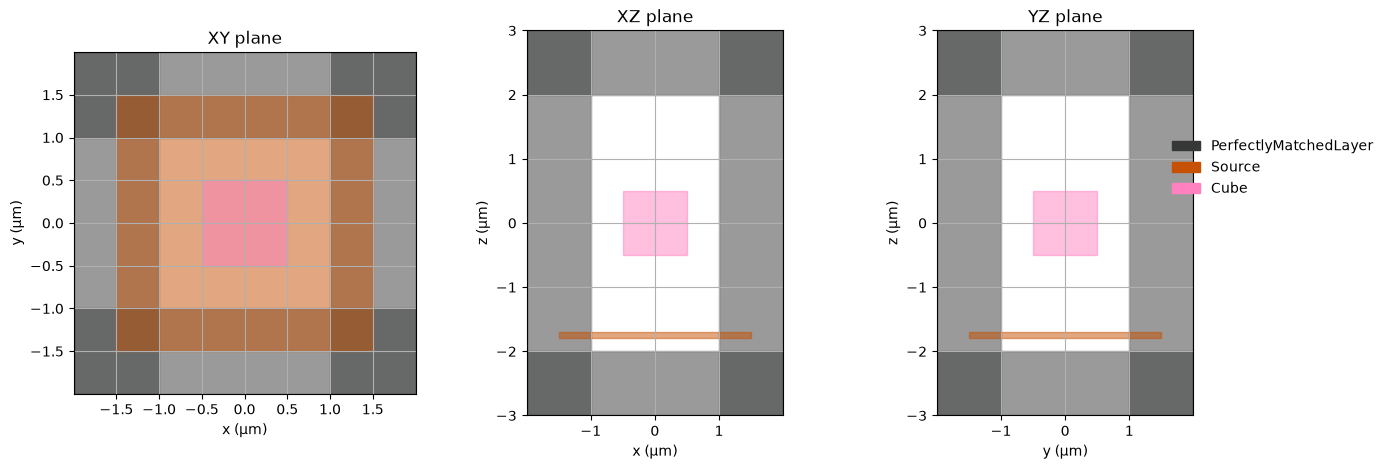

In [62]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

fig = fdtdx.plot_setup(
    config=config,
    objects=objects,
    exclude_object_list=[field_detector, energy_detector],
)
plt.show()

## 8. Preview the pulse: time signal & spectrum

Before running the full 3‑D simulation, it's worth to do a sanity-check the source's temporal profile —
its envelope in time, and its power spectrum with the three probe wavelengths (dashed lines) marked.
They should all sit comfortably under the spectral peak.


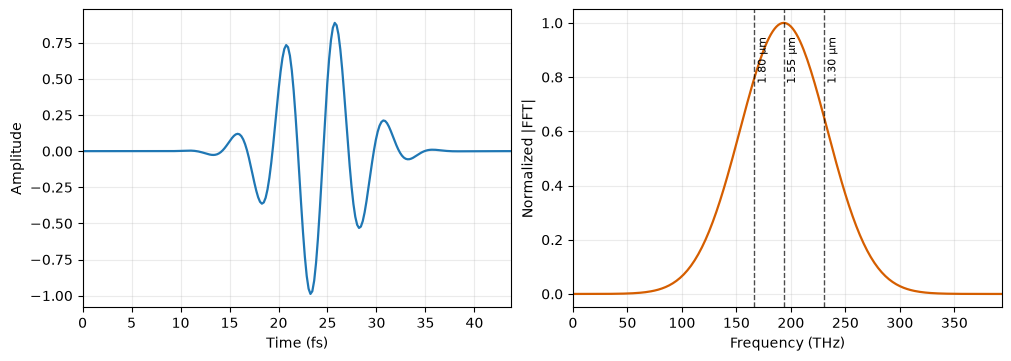

In [65]:
sig_fig = objects["Source"].plot_time_signal_and_spectrum()

c0 = fdtdx.constants.c
for wl in PROBE_WAVELENGTHS:
    freq_thz = (c0 / wl) * 1e-12  # the spectrum subplot's x-axis is in THz
    sig_fig.axes[1].axvline(freq_thz, color="k", linestyle="--", linewidth=1, alpha=0.7)
    sig_fig.axes[1].annotate(
        f"{wl * 1e6:.2f} µm",
        xy=(freq_thz, 1.0),
        xytext=(2, -10),
        textcoords="offset points",
        rotation=90,
        fontsize=8,
        va="top",
    )
plt.show()

## 9. Run the simulation with a dynamic energy-based stop condition

`fdtdx.run_fdtd` normally runs for the full `config.time_steps_total` steps
(`stopping_condition=None`, which defaults to a plain `TimeStepCondition`). Passing an
`EnergyThresholdCondition` instead makes the run stop as soon as the *total* field energy in the
volume drops below `threshold` — i.e. once the pulse has essentially left the volume (radiated out
through the PML) or been absorbed:

- `threshold` — energy level (in the same units `compute_energy` returns) below which the simulation
  is considered "done". This needs to be tuned relative to how much energy the source injects; here it
  works out to roughly 9 orders of magnitude below the peak.
- `min_steps` — defaults to 10% of `config.time_steps_total`; convergence isn't even checked before
  this, so the source has time to fully turn on first.
- `max_steps` — defaults to `config.time_steps_total`; a hard cutoff regardless of energy, so a
  misbehaving/non-decaying setup can't run forever.

This condition is evaluated every single time step, so — unlike a source or detector `OnOffSwitch`,
which is a fixed, precomputed schedule — it's a genuinely *dynamic* stop: the number of steps actually
executed is only known once the run finishes, which is exactly why the `PhasorDetector` above uses
`scaling_mode="pulse"` rather than `"continuous"`.


In [68]:
stopping_condition = EnergyThresholdCondition(threshold=1e-8)


def sim_fn(params, arrays, key):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config,
        key=key,
        stopping_condition=stopping_condition,
    )
    return final_state


start_time = time.time()
jitted_sim_fn = jax.jit(sim_fn).lower(params, arrays, subkey).compile()
print(f"Compilation time: {time.time() - start_time:.2f} s")

start_time = time.time()
final_time_step, new_arrays = jitted_sim_fn(params, arrays, subkey)
final_time_step = int(final_time_step)
print(f"Simulation runtime: {time.time() - start_time:.2f} s")
print(
    f"Stopped after {final_time_step} / {config.time_steps_total} time steps "
    f"({100 * final_time_step / config.time_steps_total:.1f}% of the max budget)"
)

Compilation time: 0.35 s


FDTD (checkpointed):   0%|                           | 0/3147 [00:00<?, ?step/s]

Simulation runtime: 0.92 s
Stopped after 1274 / 3147 time steps (40.5% of the max budget)


## 10. Energy decay curve — where did the dynamic shutoff kick in?

The detector array is preallocated for the full `config.time_steps_total` steps, but since the loop
stopped early, everything after `final_time_step` is left at its initial value (zero) — so we trim to
`[:final_time_step]` before plotting.


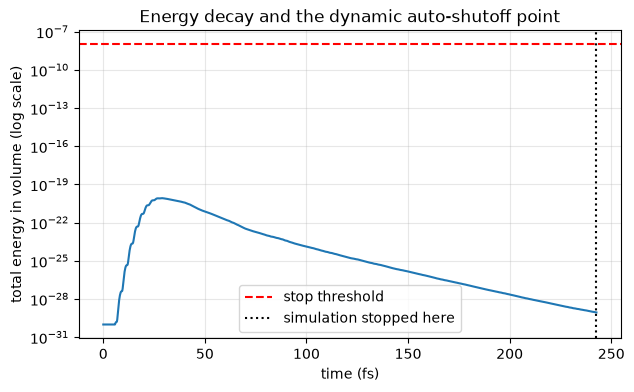

In [71]:
energy_trace = np.asarray(new_arrays.detector_states["Energy"]["energy"]).ravel()
energy_trace = energy_trace[:final_time_step]
time_axis_fs = np.arange(final_time_step) * config.time_step_duration * 1e15

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(time_axis_fs, np.maximum(energy_trace, 1e-30))
ax.axhline(stopping_condition.threshold, color="r", linestyle="--", label="stop threshold")
ax.axvline(time_axis_fs[-1], color="k", linestyle=":", label="simulation stopped here")
ax.set_xlabel("time (fs)")
ax.set_ylabel("total energy in volume (log scale)")
ax.set_title("Energy decay and the dynamic auto-shutoff point")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 11. Plotting the complex field components at each wavelength

`new_arrays.detector_states["Fields"]["phasor"]` has shape
`(1, num_wavelengths, num_components, nx, 1, nz)` — a single accumulated complex snapshot per
wavelength/component, over our x–z center plane. We plot the **real part**, **imaginary part**, and
**magnitude** of `Ex`, `Ey`, `Ez` for every probe wavelength, with the cube's outline overlaid (computed
directly from the placed objects' grid coordinates, so it's always exactly correct).


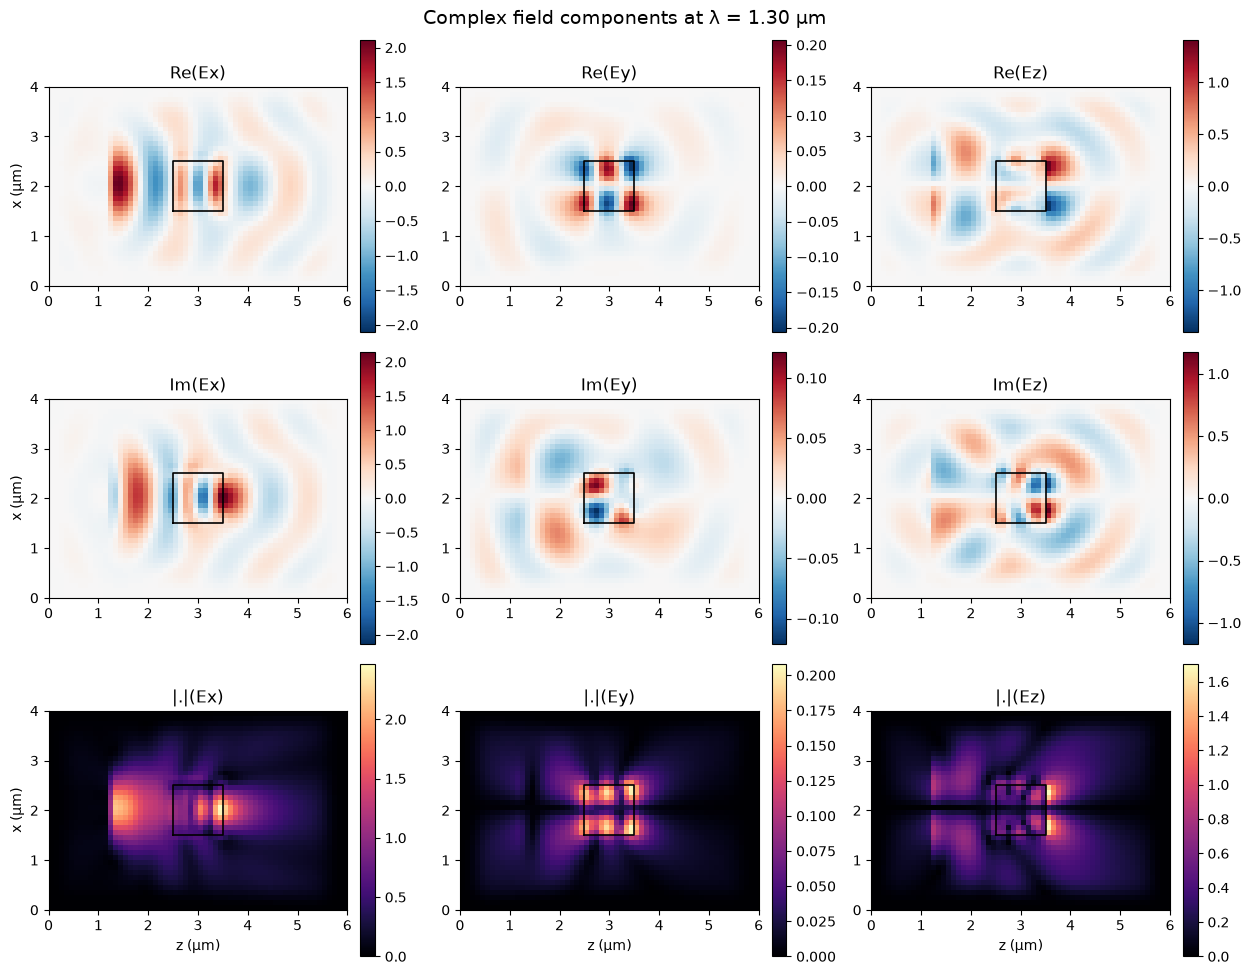

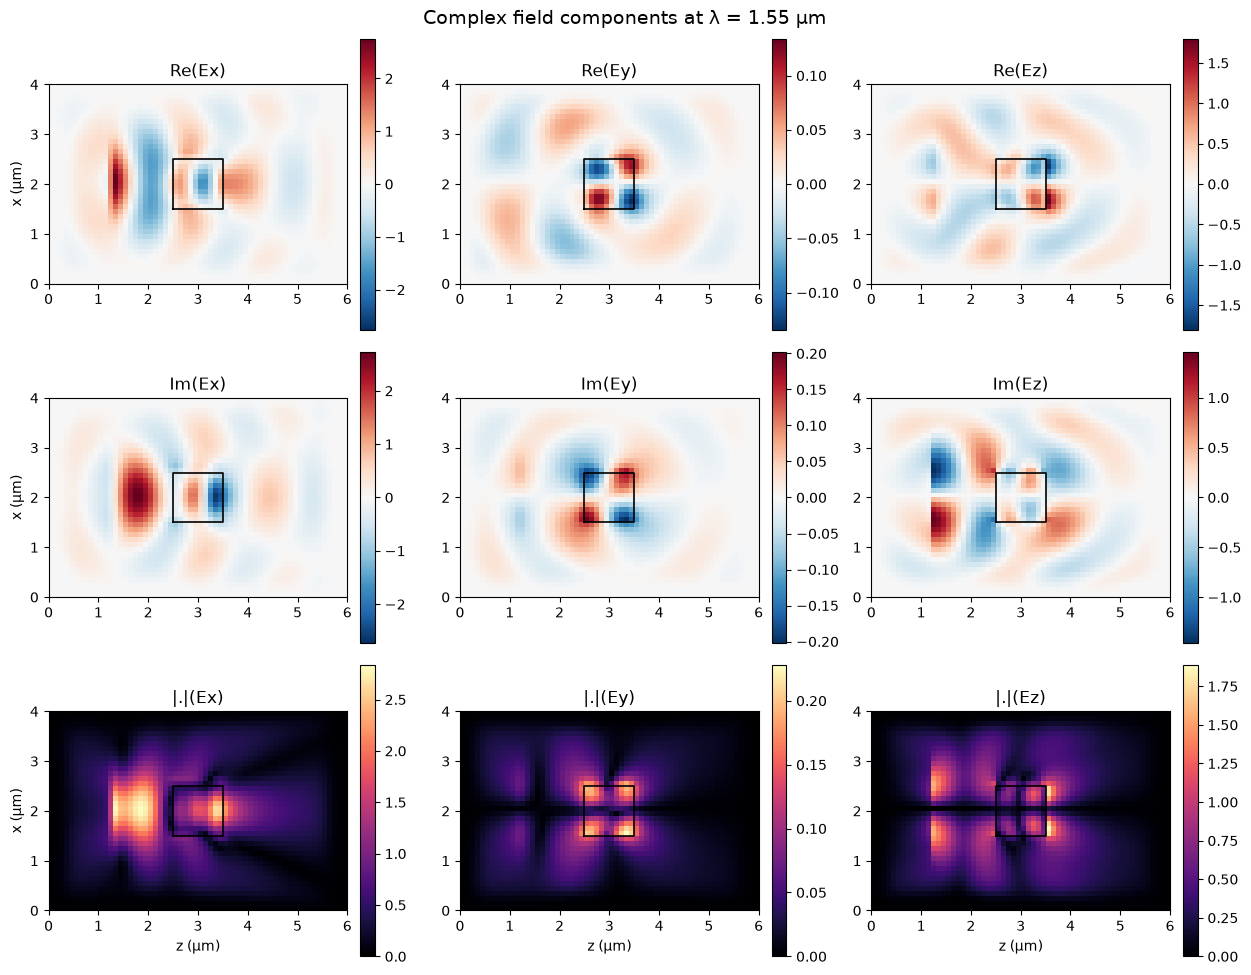

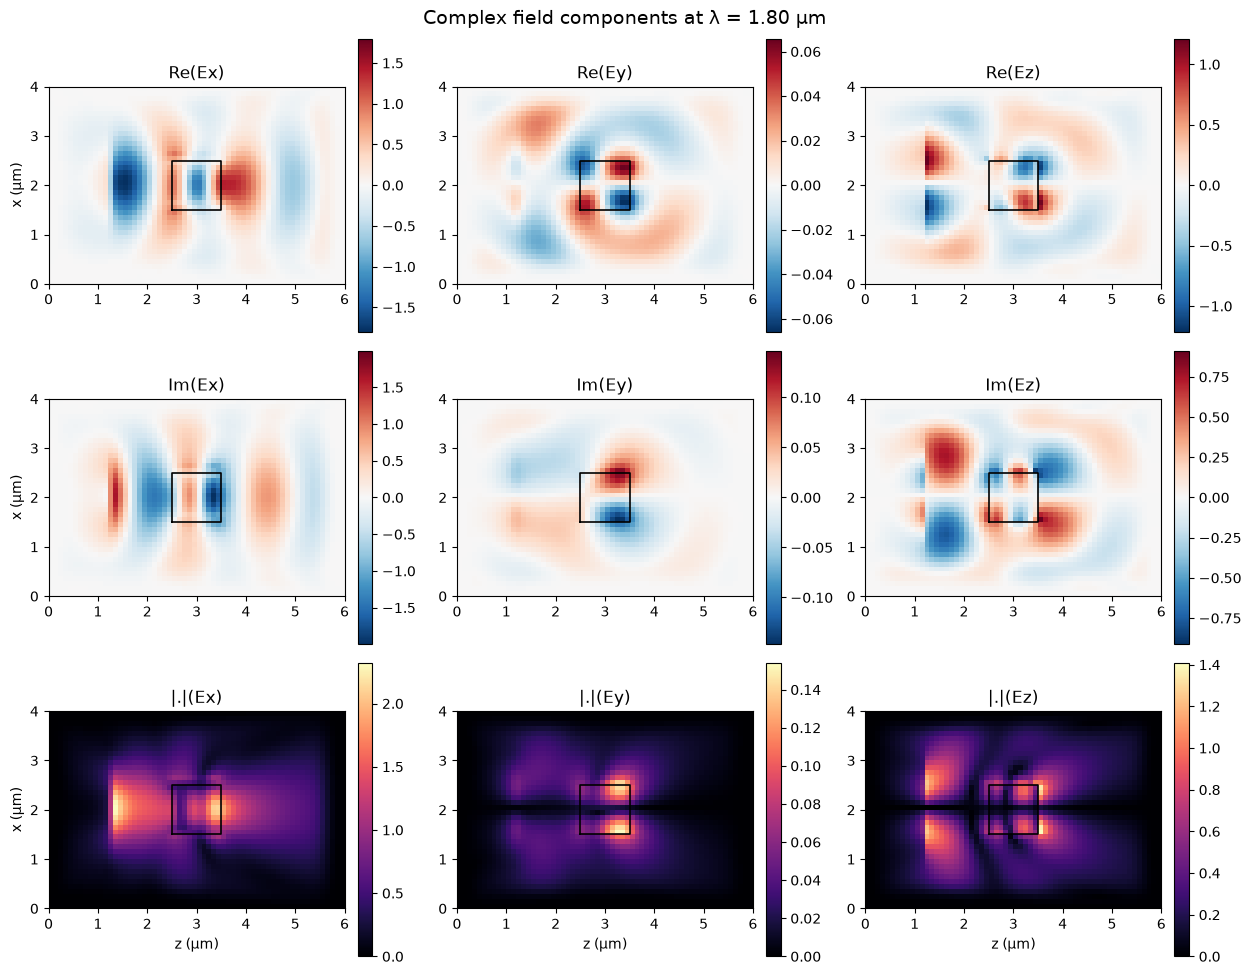

In [74]:
# phasor shape: (1, n_wavelengths, n_components, nx, 1, nz) -> squeeze the leading
# time axis and the 1-cell-thick y axis
phasor = np.asarray(new_arrays.detector_states["Fields"]["phasor"])[0, :, :, :, 0, :]
component_names = list(field_detector.components)

# Cube outline in the field-plot's local (x, z) pixel frame, converted to microns.
cube_slice = objects["Cube"].grid_slice_tuple
det_slice = objects["Fields"].grid_slice_tuple
cube_x = ((cube_slice[0][0] - det_slice[0][0]) * RESOLUTION * 1e6,
          (cube_slice[0][1] - det_slice[0][0]) * RESOLUTION * 1e6)
cube_z = ((cube_slice[2][0] - det_slice[2][0]) * RESOLUTION * 1e6,
          (cube_slice[2][1] - det_slice[2][0]) * RESOLUTION * 1e6)

nx = phasor.shape[2]
nz = phasor.shape[3]
extent = [0, nz * RESOLUTION * 1e6, 0, nx * RESOLUTION * 1e6]  # [z_min, z_max, x_min, x_max] in µm


def draw_cube_outline(ax):
    ax.plot(
        [cube_z[0], cube_z[1], cube_z[1], cube_z[0], cube_z[0]],
        [cube_x[0], cube_x[0], cube_x[1], cube_x[1], cube_x[0]],
        color="black",
        linewidth=1.2,
    )


def plot_component_at_wavelength(wl_idx, wavelength_m, component_names_to_plot=("Ex", "Ey", "Ez")):
    fig, axs = plt.subplots(3, len(component_names_to_plot), figsize=(4.2 * len(component_names_to_plot), 10))
    fig.suptitle(f"Complex field components at \u03bb = {wavelength_m * 1e6:.2f} \u00b5m", fontsize=14)

    for col, comp in enumerate(component_names_to_plot):
        comp_idx = component_names.index(comp)
        field_slice = phasor[wl_idx, comp_idx]  # complex, shape (nx, nz)

        panels = [
            ("Re", np.real(field_slice), "RdBu_r"),
            ("Im", np.imag(field_slice), "RdBu_r"),
            ("|.|", np.abs(field_slice), "magma"),
        ]
        for row, (label, data, cmap) in enumerate(panels):
            ax = axs[row, col]
            vmax = np.abs(data).max() if label != "|.|" else data.max()
            vmin = -vmax if label != "|.|" else 0.0
            im = ax.imshow(data, origin="lower", extent=extent, aspect="equal", cmap=cmap, vmin=vmin, vmax=vmax)
            draw_cube_outline(ax)
            ax.set_title(f"{label}({comp})")
            if row == 2:
                ax.set_xlabel("z (\u00b5m)")
            if col == 0:
                ax.set_ylabel("x (\u00b5m)")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    return fig


for wl_idx, wl in enumerate(PROBE_WAVELENGTHS):
    plot_component_at_wavelength(wl_idx, wl)
    plt.show()

## 12. Magnetic field components too

The detector also recorded `Hx, Hy, Hz` since we asked for all six components — same plotting
function, just point it at the H components instead.


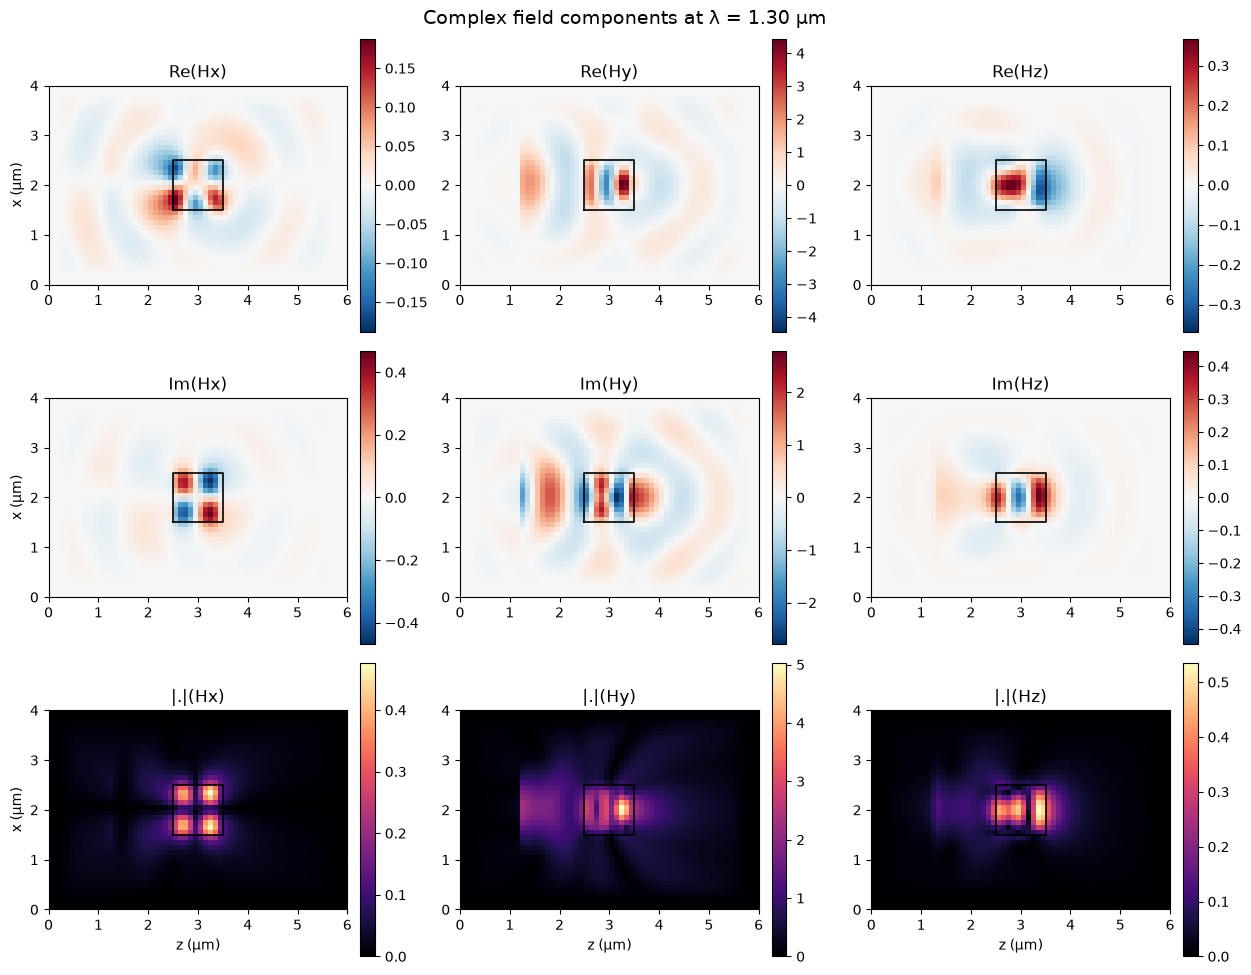

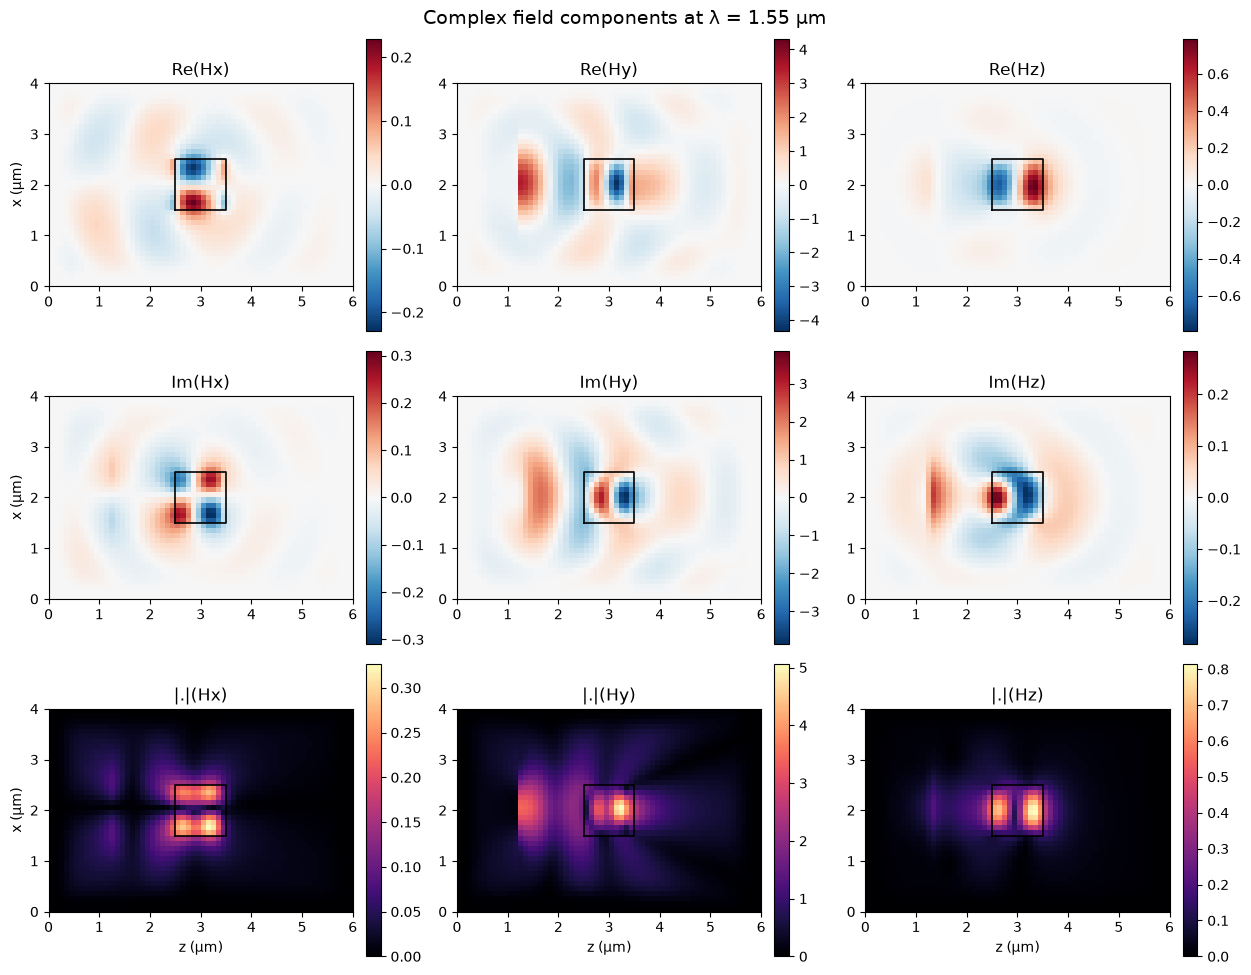

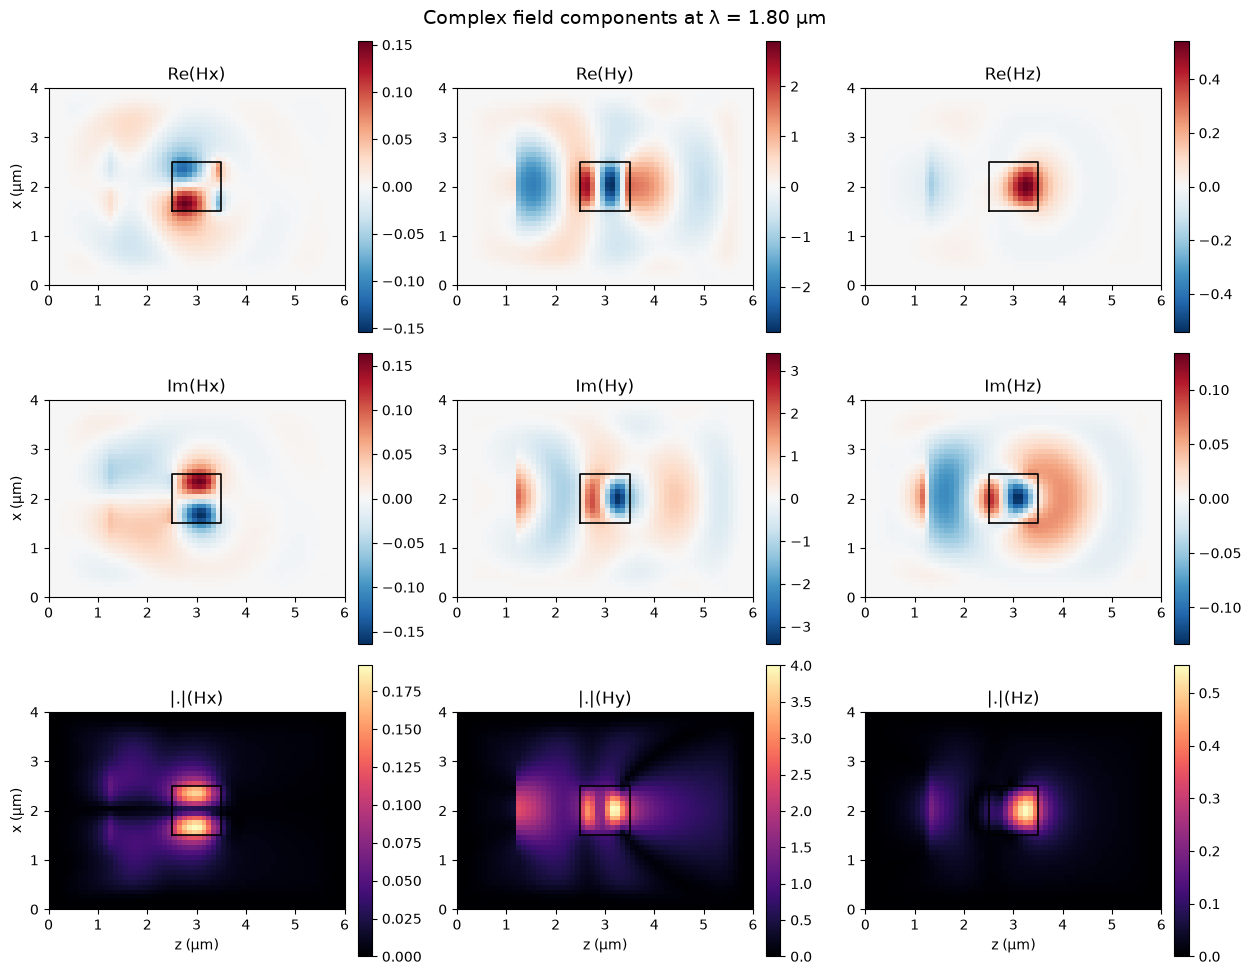

In [77]:
for wl_idx, wl in enumerate(PROBE_WAVELENGTHS):
    plot_component_at_wavelength(wl_idx, wl, component_names_to_plot=("Hx", "Hy", "Hz"))
    plt.show()